# Project covid MF order parameters and gisaid sequences on a 2D map




In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import pearsonr
from utils_mean_field import *
from script_mean_field_covid import *
# from utils_analysis_mf import *


main_path = "../"

sys.path.append(main_path + "PGM/source/")
sys.path.append(main_path + "PGM/utilities/")
import utilities, Proteins_utils, sequence_logo, plots_utils
sys.path.append(main_path + "covid/")
sys.path.append(main_path + "lattice/")
os.chdir(main_path + "covid/")

from global_variables import *
from utils_evaluate_seq import *
os.chdir('../mean_field_theory')



e:\ESCAPE_PATHS\covid\../PGM/source\numba_utilities.py:1124: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'F', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  dmean_v_dw = np.dot(s1.T, V)
e:\ESCAPE_PATHS\covid\../PGM/source\numba_utilities.py:961: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  mean_V = np.dot(weights, V) / sum_weights


Loaded 29 KD vectors


C:\Users\maria\AppData\Roaming\Python\Python312\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


# Read results

# PATH CONSTANTS

In [2]:
PROT_INIT = Proteins_utils.load_FASTA("../covid/exp_data/wt_omicron.fasta")[0]
BA1=Proteins_utils.load_FASTA("../covid/exp_data/wt_omicron.fasta")[1]
PROT_INIT = PROT_INIT[BEGIN:-END]
WT=PROT_INIT
BA1=BA1[BEGIN:-END]
L = PROT_INIT.shape[0]

class customed_covid_rbm:
    def __init__(self, rbm_model, beta_w=0):
        self.rbm_model = rbm_model
        self.beta_w = beta_w

    def __call__(self, v):
        score = -self.rbm_model.free_energy(v)[0] - get_ab_energy(v) * self.beta_w

        return score
rbm=customed_covid_rbm(RBM, beta_w=1)
print("Loading RBM model...")
print("wildtype", rbm(PROT_INIT))

Loading RBM model...
wildtype 1348.4423719960373


In [3]:
ab_names = list(ESCAPE_VECTORS.keys())
wab = np.zeros((L, 20, len(ab_names)))
for idx, ab in enumerate(ab_names):
    w_ab = ESCAPE_VECTORS[ab].reshape(L, 20)  # "no bias"
    wab[:, :, idx] = w_ab
#put last dimension first
wab = np.moveaxis(wab, -1, 0)
print("wab shape", wab.shape)
wgamma_flat= wab.reshape(wab.shape[0], -1)

wgamma_flat.shape

wab shape (29, 178, 20)


(29, 3560)

# Gisaid sequences

In [4]:
VOCS=Proteins_utils.load_FASTA("../covid/gisaid/sequences_vocs.fasta", drop_duplicates=False)
VOCS = VOCS[:,BEGIN:-END]
def extract_voc_names_from_fasta(fasta_path):
    """
    Extracts VOC names from a FASTA file.
    Assumes each entry starts with a '>' followed by the VOC name.
    """
    voc_names = []
    with open(fasta_path, 'r') as f:
        for line in f:
            if line.startswith('>'):
                voc_name = line[1:].strip()
                voc_names.append(voc_name)
    return voc_names
# List of VOCs to keep
KEEP = {"BA.5", "XBB", "BQ.1.1", "WT"}

# Extract all VOC names
VOC_NAMES = extract_voc_names_from_fasta("../covid/gisaid/sequences_vocs.fasta")

# Build mask for selected VOCs
mask = [any(name.startswith(k) for k in KEEP) for name in VOC_NAMES]

# Apply mask to names and sequences
VOC_NAMES = [name for name, keep in zip(VOC_NAMES, mask) if keep]
VOCS = VOCS[mask,:]
VOCS.shape

(4, 178)

In [5]:
rbd_dates = pd.read_csv('../covid/gisaid/rbd_dates.csv')
print(rbd_dates.shape)
rbd_dates['q05_date'] = pd.to_datetime(rbd_dates['q05_date'])
seqs=Proteins_utils.load_FASTA('../covid/gisaid/rbd_dates_with_sequence.fasta')
one_hot_seqs=np.array([one_hot_encode_concat(seq) for seq in seqs])
# get indexes of 'count' >1
rbd_dates=rbd_dates[rbd_dates['count']>1]

indexes = rbd_dates[rbd_dates['count'] > 0].index
rbd_dates = rbd_dates.iloc[indexes]
print("rbd_dates", rbd_dates.shape)
one_hot_seqs = one_hot_seqs[indexes]
one_hot_seqs.shape


(8167, 3)
rbd_dates (4025, 3)


(4025, 3560)

# Get order parameters

In [6]:
# folder = 'results_scripts/D_20_covid/mean_f_free_ab_beta_ab_1_D_20_beta_phi_1'
folder='results_scripts/covid_D_20/mean_f_free_ab_beta_ab_1._D_20'
mopt = np.load(f"{folder}/mopt.npy") [:,:29]*L
mopt.shape#(21, 29)



(21, 29)

In [7]:
def project_without_blas(one_hot_seqs, wgamma_flat):
    """
    Project each of N sequences (length-D) onto each of K axes,
    without calling the BLAS-backed dot() function.
    Returns an (N, K) array of projections.
    """
    N, D = one_hot_seqs.shape
    K, D2 = wgamma_flat.shape
    assert D == D2
    
    # pre-allocate output
    projections = np.empty((N, K), dtype=one_hot_seqs.dtype)
    
    # for each axis, multiply elementwise and sum
    for k in range(K):
        # Broadcast: (N, D) * (D,) → (N, D), then sum over D → (N,)
        projections[:, k] = (one_hot_seqs * wgamma_flat[k]).sum(axis=1)
    
    return projections


# Get MCMC paths

In [8]:
def get_mcmc_proba_aa(dir,wgamma_flat):
    paths_nb=100
    print("beta_w", beta_w)
    proj_mat=[]
    for path_no in range(paths_nb):
        fasta_file = os.path.join(dir, f"output_{path_no}.fasta")
        if not os.path.exists(fasta_file):
            print('not found')
            continue
        sequences = Proteins_utils.load_FASTA(fasta_file, drop_duplicates=False)
        one_hot_seqs = np.array([one_hot_encode_concat(seq) for seq in sequences])
        projs= project_without_blas(one_hot_seqs, wgamma_flat)
        proj_mat.append(projs)
    proj_mat= np.array(proj_mat)
    #mean around axis 0
    print("proj_mat", proj_mat.shape)
    return proj_mat
beta_w=1
dir_mcmc = f"../covid/paths/test_covid_T20_beta_w_{beta_w}/"
paths_mcmc=get_mcmc_proba_aa(dir_mcmc, wgamma_flat)


beta_w 1
proj_mat (100, 21, 29)


In [9]:
paths_mcmc.shape

(100, 21, 29)

# Project




In [10]:
wgamma_flat.shape

(29, 3560)

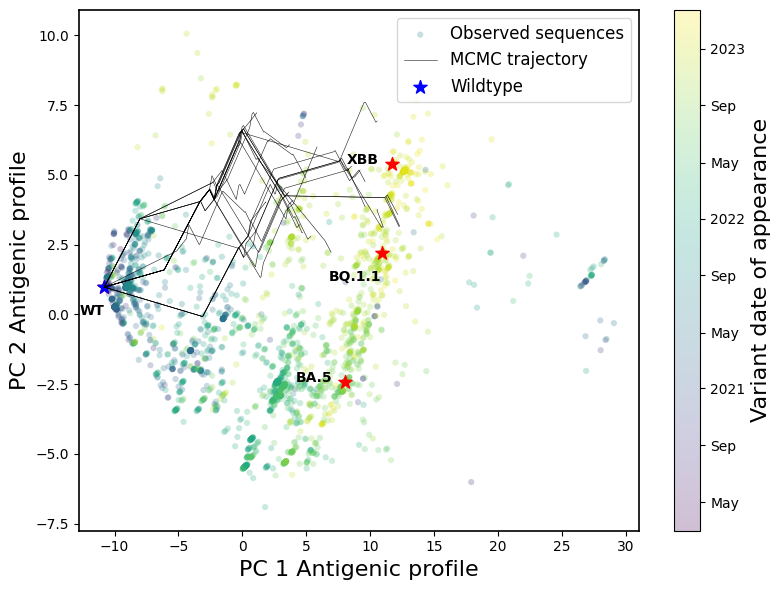

In [11]:
def project_and_plot_2d(one_hot_seqs, wgamma_flat, dates_series):


    # --- Projection onto wgamma axes ---
    projections = project_without_blas(one_hot_seqs, wgamma_flat)
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(projections)

    # --- Project reference points and trajectories ---
    wt_proj = project_without_blas(np.array([one_hot_encode_concat(WT)]), wgamma_flat)
    wt_2d = pca.transform(wt_proj)

    vocs_proj = project_without_blas(np.array([one_hot_encode_concat(voc) for voc in VOCS]), wgamma_flat)
    vocs_2d = pca.transform(vocs_proj)

    import random
    random.seed(0)  # for reproducibility
    random_idxs = random.sample(range(len(paths_mcmc)), 20)
    paths_mcmc_2d = [pca.transform(paths_mcmc[i]) for i in random_idxs]

    # --- Date coloring ---
    dates = pd.to_datetime(dates_series)
    mdates_num = mdates.date2num(dates.values.astype("datetime64[us]"))
    norm = Normalize(vmin=mdates_num.min(), vmax=mdates_num.max())

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(8, 6))

    # Scatter of observed sequences
    sc = ax.scatter(
        X_2d[:, 0], X_2d[:, 1],
        c=mdates_num, cmap='viridis',
        s=20, edgecolors='none', alpha=0.25,
        label="Observed sequences"
    )

    # --- MCMC trajectories in thick black lines (only one label) ---
    for i, path in enumerate(paths_mcmc_2d):
        label = "MCMC trajectory" if i == 0 else None
        ax.plot(path[:, 0], path[:, 1],
                color='black', linewidth=0.4, alpha=0.9,
                label=label)

    # --- VOC stars and annotations ---
    for i, (x, y) in enumerate(vocs_2d):
        ax.scatter(x, y, color='red', marker='*', s=100)
        ax.annotate(VOC_NAMES[i], (x + (i % 2 - 1) * 1, y + ((i + 1) % 2 - 1) * 1),
                    fontsize=10, fontweight='bold', color='black', ha='right')

    # --- Wildtype star ---
    ax.scatter(wt_2d[0, 0], wt_2d[0, 1], color='blue', marker='*', s=100, label='Wildtype')

    # --- Labels and colorbar ---
    ax.set_xlabel("PC 1 Antigenic profile", fontsize=16)
    ax.set_ylabel("PC 2 Antigenic profile", fontsize=16)

    cbar = fig.colorbar(sc, ax=ax, orientation='vertical')
    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    cbar.ax.yaxis_date()
    cbar.ax.yaxis.set_major_locator(locator)
    cbar.ax.yaxis.set_major_formatter(formatter)
    cbar.set_label("Variant date of appearance", fontsize=16)

    ax.legend(loc='best', frameon=True, fontsize=12)

    # --- PRL-style black frame ---
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.2)

    plt.tight_layout()
    plt.show()

project_and_plot_2d(one_hot_seqs, wgamma_flat, rbd_dates['q05_date'])


# Evolution of ab resistance by step

In [12]:
paths_mcmc.shape

(100, 21, 29)

In [13]:
mean_paths=np.mean(paths_mcmc, axis=0)[:,:]
mean_paths.shape


(21, 29)

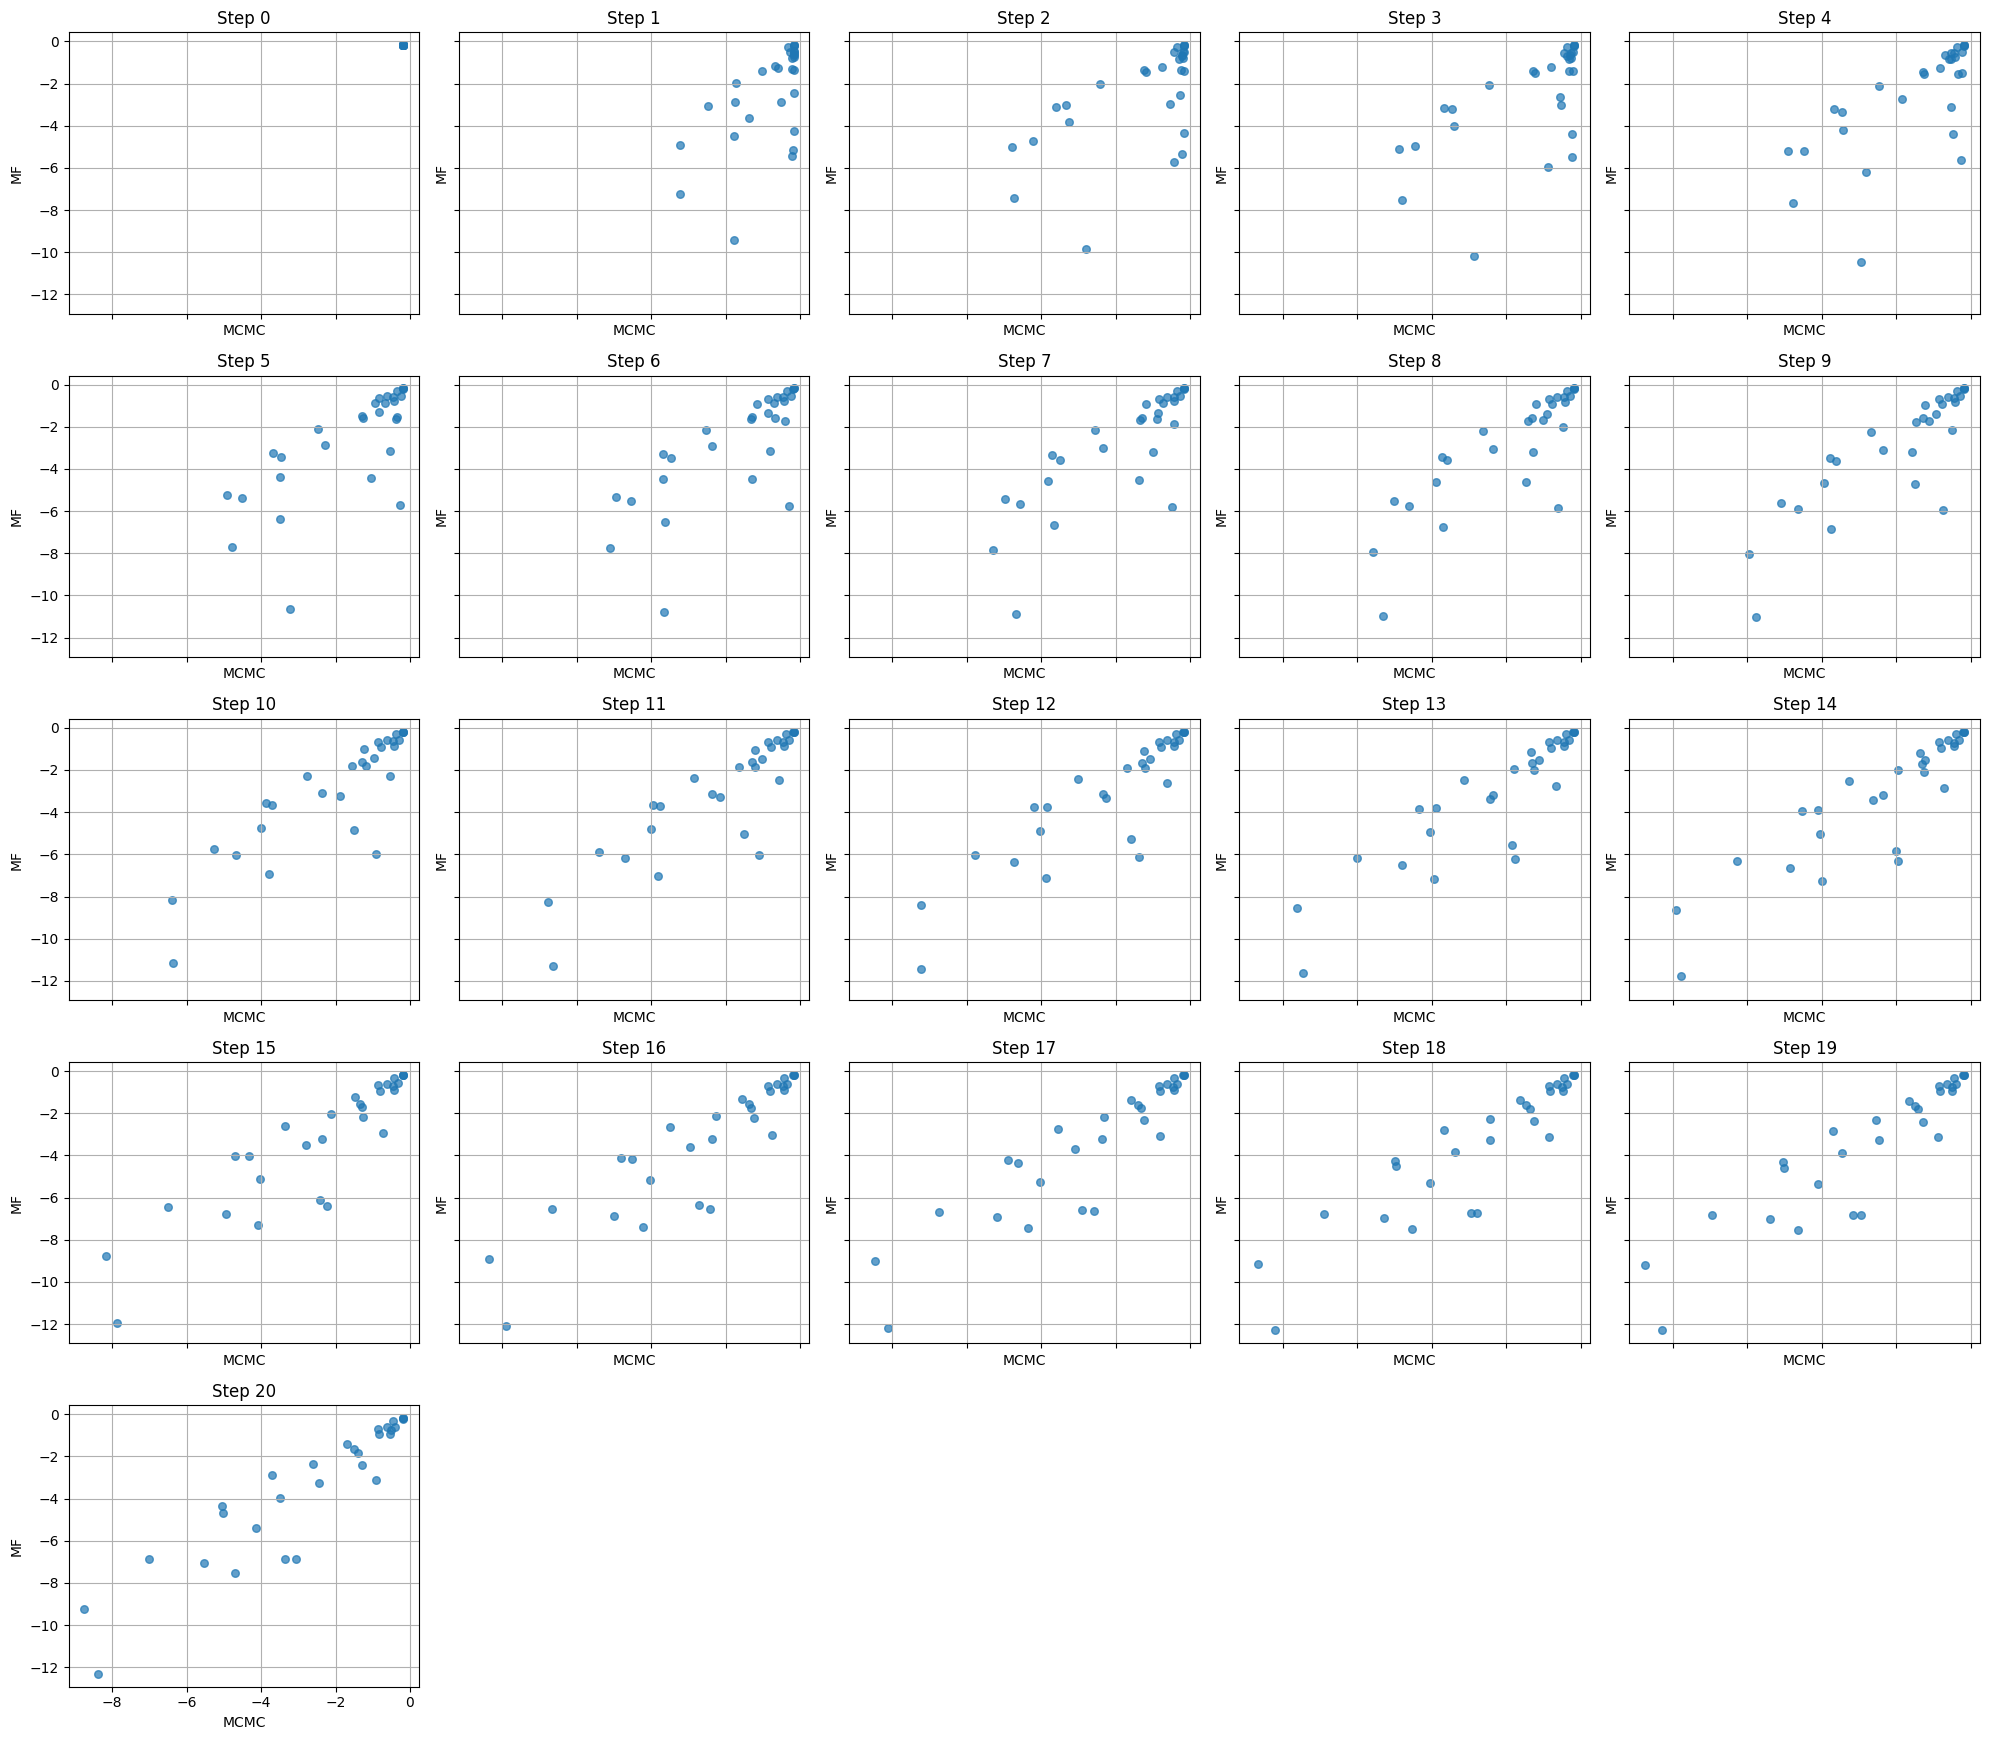

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Assume mean_paths and mopt have shape (20, 29)
n_steps = mean_paths.shape[0]

# Plot config
ncols = 5
nrows = (n_steps + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(n_steps):
    ax = axes[i]
    ax.scatter(mean_paths[i], mopt[i], s=30, alpha=0.7)
    ax.set_title(f"Step {i}")
    ax.set_xlabel("MCMC")
    ax.set_ylabel("MF")
    ax.grid(True)

# Hide extra subplots
for j in range(n_steps, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [15]:
ab_class_df=pd.read_csv('../covid/exp_data/bloom_ab_classification/ab_classification.csv')
import matplotlib.pyplot as plt

# Map class information to each antibody in df
class_mapping = ab_class_df.set_index('condition')['condition_subtype'].to_dict()
class_mapping

{'COV2-2196': 'class 1',
 'COV2-2130': 'class 3',
 'COV2-2955': 'class 2',
 'CR3022': 'class 4',
 'COV2-2677': 'class 4',
 'COV2-2082': 'class 4',
 'COV2-2094': 'class 4',
 'COV2-2165': 'class 1',
 'COV2-2832': 'class 1',
 'COV2-2479': 'class 2',
 'COV2-2050': 'class 2',
 'COV2-2096': 'class 2',
 'COV2-2499': 'class 3',
 'C002': 'class 2',
 'C105': 'class 1',
 'C110': 'class 3',
 'C121': 'class 2',
 'C135': 'class 3',
 'C144': 'class 2',
 'LY-CoV555': 'class 2',
 'REGN10933': 'class 1',
 'REGN10987': 'class 3',
 'LY-CoV016': 'class 1',
 'S309': 'class 3',
 'S2H97': 'class 4',
 'S304': 'class 4',
 'S2X35': 'class 4',
 'S2E12': 'class 1',
 'S2X16': 'class 2',
 'S2H58': 'class 2',
 'S2H13': 'class 2',
 'S2D106': 'class 2',
 'S2X58': 'class 2',
 'S2H14': 'class 1',
 'S2X227': 'class 3',
 'S2X259': 'class 4'}

In [16]:


# Convert ab_names to classes
ab_classes = [class_mapping.get(ab, 'Unknown') for ab in ab_names]

# Define class colors
unique_classes = sorted(set(ab_classes))
palette = plt.get_cmap("tab10")
class_to_color = {cls: palette(i) for i, cls in enumerate(unique_classes)}
colors = [class_to_color[c] for c in ab_classes]

# Steps to plot


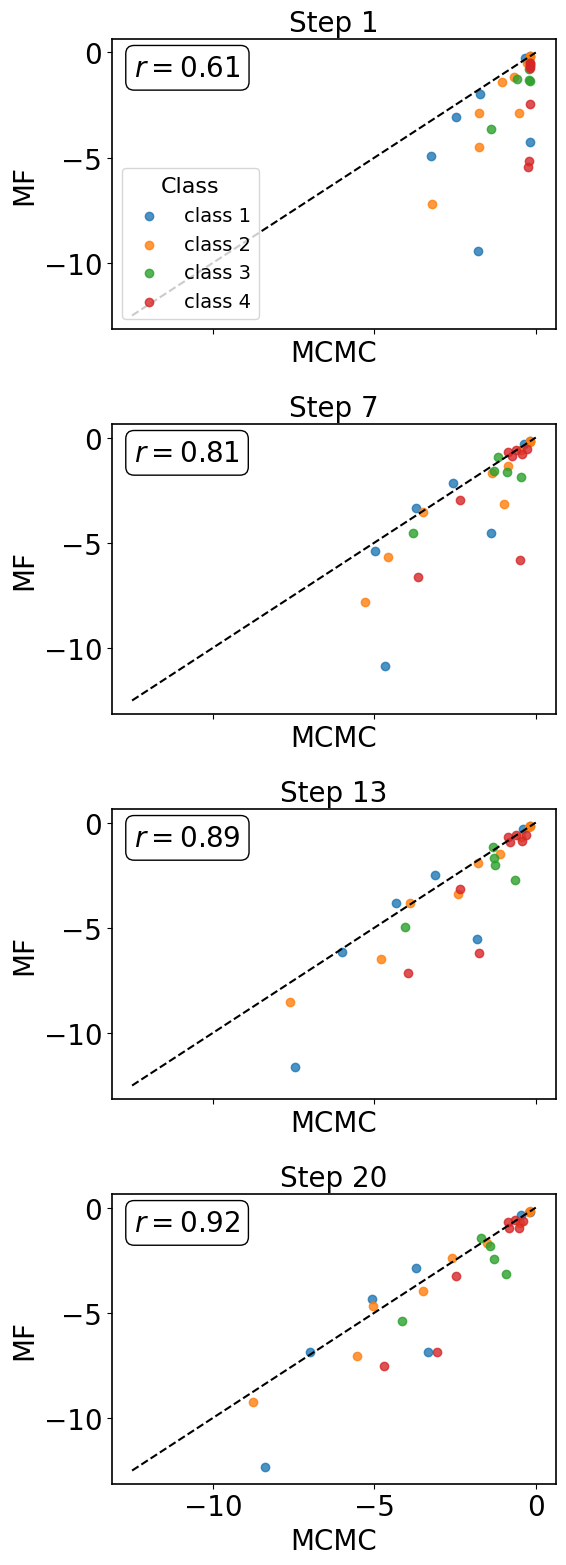

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

steps_to_plot = [1, 7, 13, 20]

# Set up plot with larger fonts
plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'legend.fontsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16
})

n_steps = len(steps_to_plot)
ncols = 1
nrows = n_steps  # one plot per row

fig, axes = plt.subplots(nrows, ncols, figsize=(6, 4 * nrows), sharex=True, sharey=True)

# If only one axis, wrap in list to make iterable
if n_steps == 1:
    axes = [axes]

for i, step in enumerate(steps_to_plot):
    ax = axes[i]
    x = mean_paths[step]
    y = mopt[step]
    
    for cls in unique_classes:
        idx = [j for j, c in enumerate(ab_classes) if c == cls]
        ax.scatter(np.array(x)[idx], np.array(y)[idx], label=cls, color=class_to_color[cls], alpha=0.8)
    
    # Pearson correlation
    r, _ = pearsonr(x, y)
    ax.text(
        0.05, 0.95, f"$r = {r:.2f}$", transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='left',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'),
        fontsize=20
    )

    ax.set_title(f"Step {step}", fontsize=20)
    ax.set_xlabel("MCMC", fontsize=20)
    ax.set_ylabel("MF", fontsize=20)

    ax.tick_params(axis='x', labelsize=20)
    ax.tick_params(axis='y', labelsize=20)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.2)
    ax.plot([-12.5, 0], [-12.5, 0], linestyle='--', color='black')

# Legend inside the first subplot
axes[0].legend(
    title='Class',
    loc='lower left',
    fontsize=14,
    title_fontsize=16,
    frameon=True
)

plt.tight_layout()
plt.show()


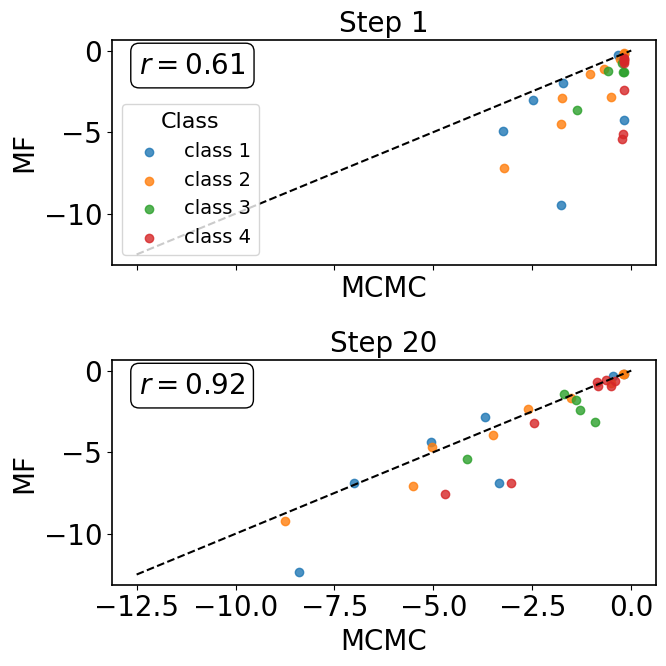

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

steps_to_plot = [1, 20]

# Set up plot with larger fonts
plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'legend.fontsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16
})

n_steps = len(steps_to_plot)
ncols = 1
nrows = n_steps  # one plot per row

fig, axes = plt.subplots(nrows, ncols, figsize=(7, 3.5 * nrows), sharex=True, sharey=True)

# If only one axis, wrap in list to make iterable
if n_steps == 1:
    axes = [axes]

for i, step in enumerate(steps_to_plot):
    ax = axes[i]
    x = mean_paths[step]
    y = mopt[step]
    
    for cls in unique_classes:
        idx = [j for j, c in enumerate(ab_classes) if c == cls]
        ax.scatter(np.array(x)[idx], np.array(y)[idx], label=cls, color=class_to_color[cls], alpha=0.8)
    
    # Pearson correlation
    r, _ = pearsonr(x, y)
    ax.text(
        0.05, 0.95, f"$r = {r:.2f}$", transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='left',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'),
        fontsize=20
    )

    ax.set_title(f"Step {step}", fontsize=20)
    ax.set_xlabel("MCMC", fontsize=20)
    ax.set_ylabel("MF", fontsize=20)

    ax.tick_params(axis='x', labelsize=20)
    ax.tick_params(axis='y', labelsize=20)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.2)
    ax.plot([-12.5, 0], [-12.5, 0], linestyle='--', color='black')

# Legend inside the first subplot
axes[0].legend(
    title='Class',
    loc='lower left',
    fontsize=14,
    title_fontsize=16,
    frameon=True
)

plt.tight_layout()
plt.show()


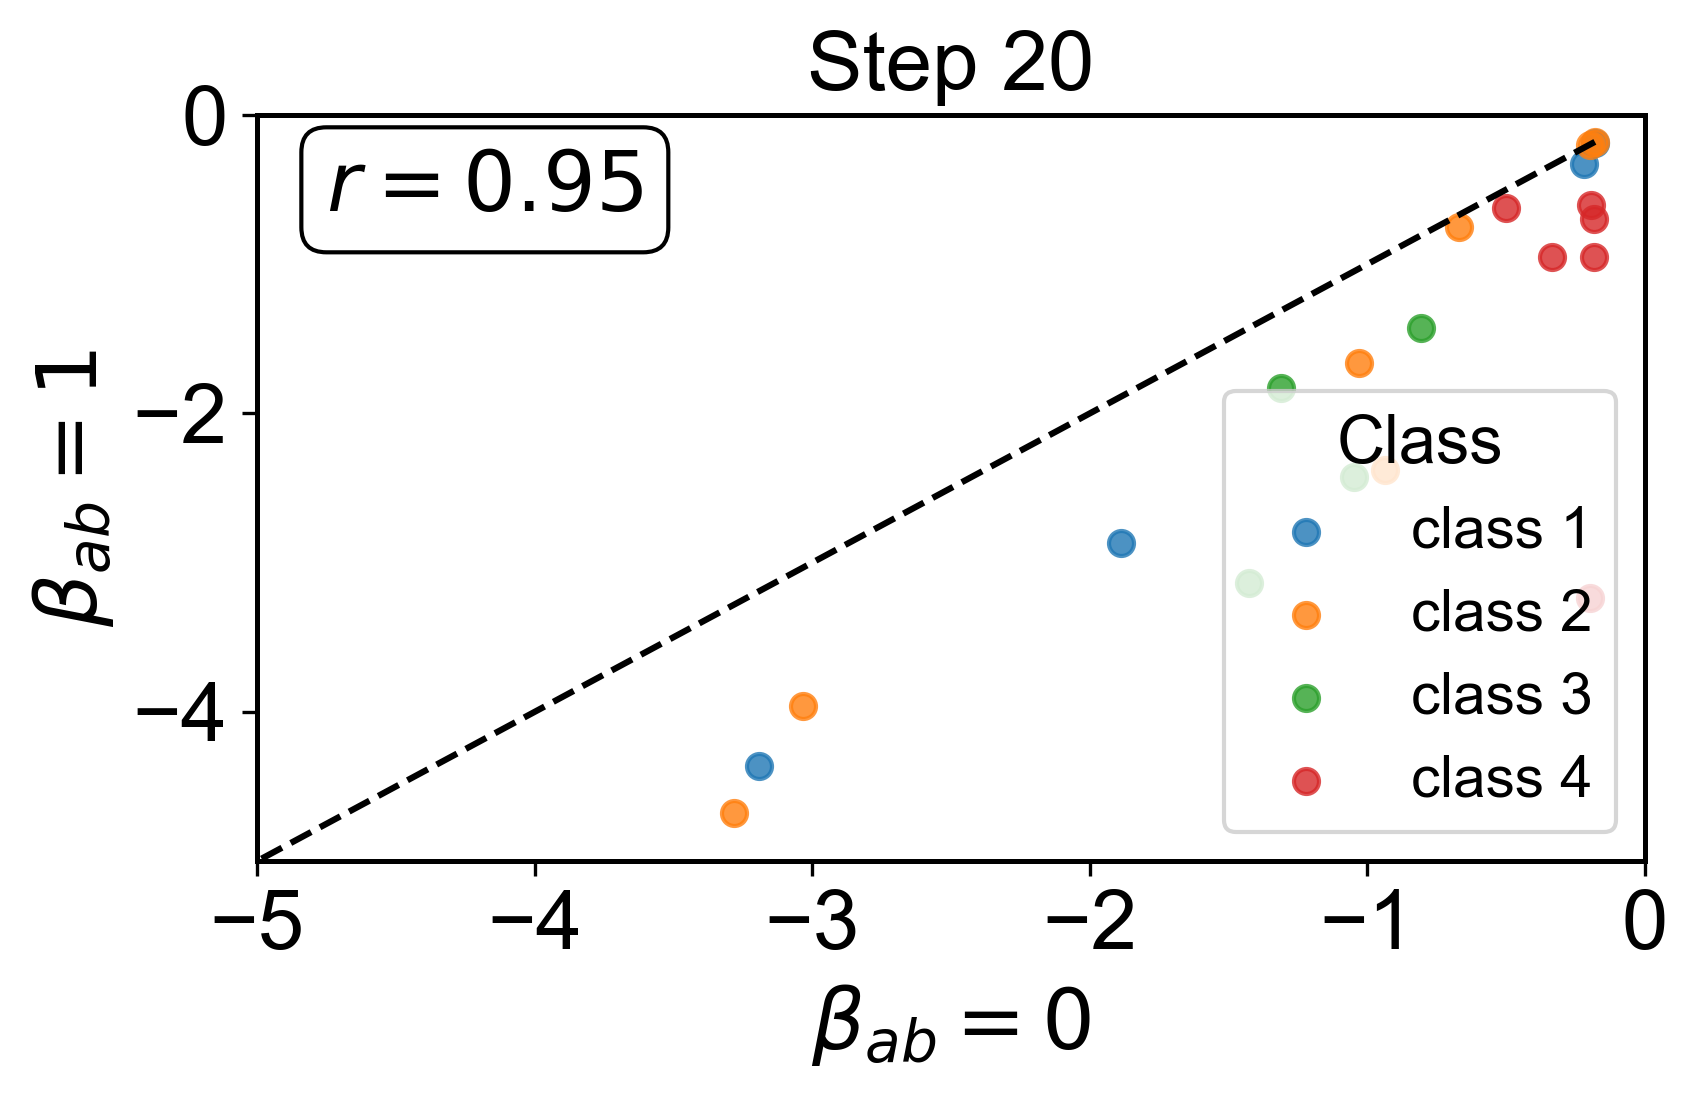

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# --- Load both MF trajectories ---
folder1 = 'results_scripts/covid_D_20/mean_f_free_ab_beta_ab_1._D_20'
folder0 = 'results_scripts/covid_D_20/mean_f_free_ab_beta_ab_0._D_20'

mopt_beta1 = np.load(f"{folder1}/mopt.npy")[:, :29] * L   # (21,29)
mopt_beta0 = np.load(f"{folder0}/mopt.npy")[:, :29] * L   # (21,29)

steps_to_plot = [20]

plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'legend.fontsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16
})

n_steps = len(steps_to_plot)
fig, axes = plt.subplots(n_steps, 1, figsize=(6, 4 * n_steps), sharex=True, sharey=True)

if n_steps == 1:
    axes = [axes]

for i, step in enumerate(steps_to_plot):
    ax = axes[i]

    x = mopt_beta0[step]  # β_ab = 0
    y = mopt_beta1[step]  # β_ab = 1

    for cls in unique_classes:
        idx = [j for j, c in enumerate(ab_classes) if c == cls]
        ax.scatter(np.array(x)[idx], np.array(y)[idx],
                   label=cls,
                   color=class_to_color[cls],
                   alpha=0.8)

    # Correlation
    r, _ = pearsonr(x, y)
    ax.text(
        0.05, 0.95, f"$r = {r:.2f}$", transform=ax.transAxes,
        va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'),
        fontsize=20
    )

    ax.set_title(f"Step {step}", fontsize=20)
    ax.set_xlabel(r"$\beta_{ab}=0$", fontsize=20)
    ax.set_ylabel(r"$\beta_{ab}=1$", fontsize=20)

    ax.tick_params(axis='x', labelsize=20)
    ax.tick_params(axis='y', labelsize=20)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.2)

    # Reference diagonal
    ax.plot([min(x.min(), y.min()), max(x.max(), y.max())],
            [min(x.min(), y.min()), max(x.max(), y.max())],
            linestyle='--', color='black')
    ax.set_xlim([-5, 0])
    ax.set_ylim([-5, 0])

# Legend once (first subplot)
axes[0].legend(
    title='Class',
    loc='lower right',
    fontsize=14,
    title_fontsize=16,
    frameon=True
)

plt.tight_layout()
plt.show()


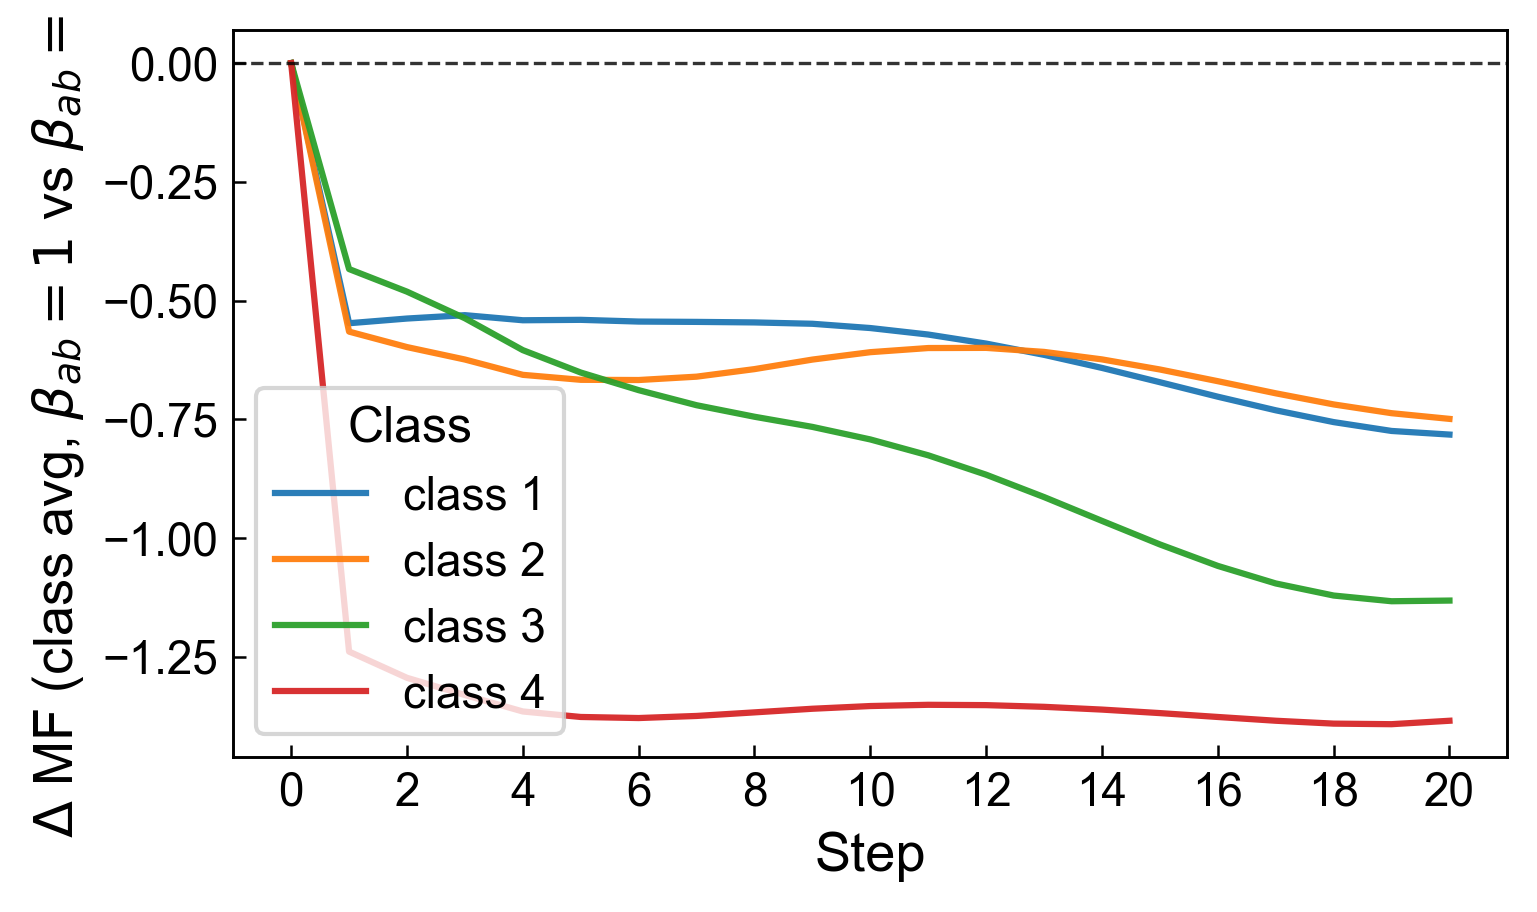

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# --- Load MF trajectories ---
base = 'results_scripts/covid_D_20'
mopt_beta0 = np.load(f'{base}/mean_f_free_ab_beta_ab_0._D_20/mopt.npy')[:, :29] * L  # (T,29)
mopt_beta1 = np.load(f'{base}/mean_f_free_ab_beta_ab_1._D_20/mopt.npy')[:, :29] * L  # (T,29)

# --- ΔMF per step, per antibody ---
delta = mopt_beta1 - mopt_beta0  # shape (T, 29)
steps = np.arange(delta.shape[0])

# --- Plot setup (no grid, full black frame) ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    'font.size': 12,
    'axes.labelsize': 13,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 300
})

fig, ax = plt.subplots(figsize=(5.2, 3.2))

# --- Average per class and plot ---
for cls in unique_classes:
    idx = [j for j, c in enumerate(ab_classes) if c == cls]
    diffs_cls = delta[:, idx]  # (T, n_cls)
    mean_cls = diffs_cls.mean(axis=1)
    std_cls  = diffs_cls.std(axis=1, ddof=1) if len(idx) > 1 else np.zeros_like(mean_cls)

    color = class_to_color[cls]
    ax.plot(steps, mean_cls, label=cls, color=color, linewidth=1.5, alpha=0.95)
    # ax.fill_between(steps, mean_cls - std_cls, mean_cls + std_cls,
    #                 color=color, alpha=0.2, linewidth=0)

# --- Styling ---
ax.axhline(0.0, ls='--', lw=0.8, color='black', alpha=0.8)
ax.set_xlabel("Step")
ax.set_ylabel(r"$\Delta$ MF (class avg, $\beta_{ab}{=}1$ vs $\beta_{ab}{=}0$)")
ax.set_xticks(np.arange(0, steps.max()+1, 2))

# Full black frame, ticks inward
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.7)
ax.tick_params(axis='both', which='both', direction='in', length=3, width=0.6)

ax.legend(title='Class', frameon=True, loc='best')
plt.tight_layout()
plt.show()


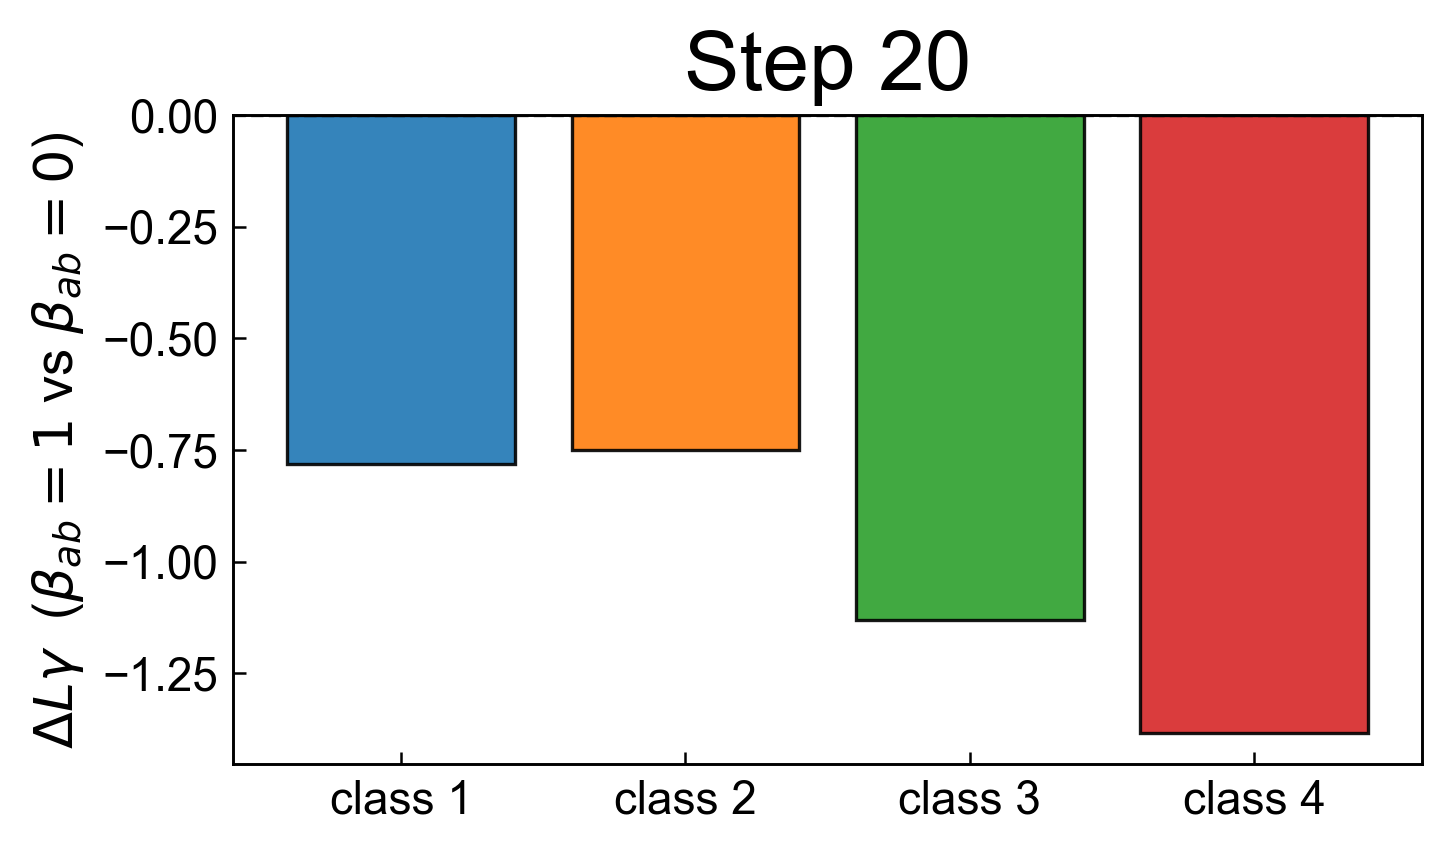

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# --- Load MF trajectories for beta=0 and beta=1 ---
base = 'results_scripts/covid_D_20'
mopt_beta0 = np.load(f'{base}/mean_f_free_ab_beta_ab_0._D_20/mopt.npy')[:, :29] * L  # (T,29)
mopt_beta1 = np.load(f'{base}/mean_f_free_ab_beta_ab_1._D_20/mopt.npy')[:, :29] * L  # (T,29)

# --- Choose step ---
step = 20
delta = mopt_beta1[step] - mopt_beta0[step]  # (29,)

# --- Order classes explicitly: class 1 → class 4 ---
ordered_classes = ["class 1", "class 2", "class 3", "class 4"]

class_means, class_colors = [], []
for cls in ordered_classes:
    idx = [j for j, c in enumerate(ab_classes) if c == cls]
    vals = delta[idx]
    class_means.append(np.mean(vals))
    class_colors.append(class_to_color[cls])

# --- Plot ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    'font.size': 12,
    'axes.labelsize': 13,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 300
})

fig, ax = plt.subplots(figsize=(5.0, 3.0))

x = np.arange(len(ordered_classes))
ax.bar(x, class_means, color=class_colors, edgecolor='black',
       alpha=0.9, linewidth=0.8)

ax.axhline(0.0, ls='--', lw=0.8, color='black', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(ordered_classes, rotation=0)
ax.set_ylabel(r'$\Delta L\gamma$  ($\beta_{ab}{=}1$ vs $\beta_{ab}{=}0$)')
ax.set_title(f'Step {step}')

# Full black frame
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.7)

ax.tick_params(axis='both', which='both', direction='in', length=3, width=0.6)

plt.tight_layout()
plt.show()


# Force parameters

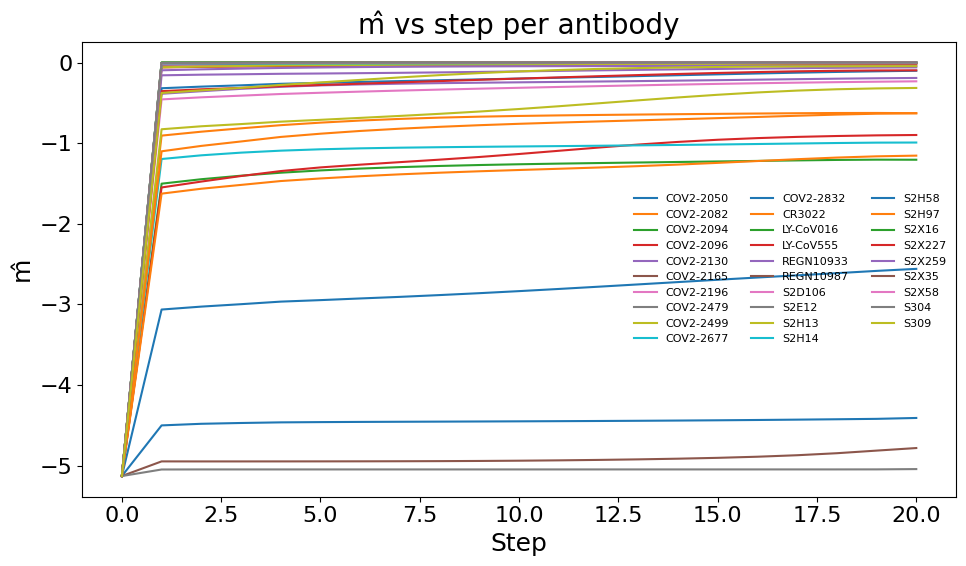

In [19]:
# folder = 'results_scripts/D_20_covid/mean_f_free_ab_beta_ab_1_D_20_beta_phi_1'
folder='results_scripts/covid_D_20/mean_f_free_ab_beta_ab_1._D_20'
mhatopt = np.load(f"{folder}/mhat_array.npy") [-1,:,:29]
mhatopt.shape#step, ab
steps = np.arange(mhatopt.shape[0])
labels = (ab_names[:mhatopt.shape[1]] 
          if 'ab_names' in globals() and len(ab_names) >= mhatopt.shape[1] 
          else [f"ab{i+1}" for i in range(mhatopt.shape[1])])

plt.figure(figsize=(10,6))
for j in range(mhatopt.shape[1]):
    plt.plot(steps, mhatopt[:, j], label=labels[j], linewidth=1.5)

plt.xlabel("Step")
plt.ylabel("m̂")
plt.title("m̂ vs step per antibody")
plt.legend(ncol=3, fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

In [20]:
ab_names

['COV2-2050',
 'COV2-2082',
 'COV2-2094',
 'COV2-2096',
 'COV2-2130',
 'COV2-2165',
 'COV2-2196',
 'COV2-2479',
 'COV2-2499',
 'COV2-2677',
 'COV2-2832',
 'CR3022',
 'LY-CoV016',
 'LY-CoV555',
 'REGN10933',
 'REGN10987',
 'S2D106',
 'S2E12',
 'S2H13',
 'S2H14',
 'S2H58',
 'S2H97',
 'S2X16',
 'S2X227',
 'S2X259',
 'S2X35',
 'S2X58',
 'S304',
 'S309']